In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [11]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.6 MB/s eta 0:00:32
    --------------------------------------- 0.8/48.9 MB 1.4 MB/s eta 0:00:34
    --------------------------------------- 1.0/48.9 MB 1.2 MB/s eta 0:00:42
    --------------------------------------- 1.0/48.9 MB 1.2 MB/s eta 0:00:42
   - -------------------------------------- 1.3/48.9 MB 1.1 MB/s eta 0:00:43
   - -------------------------------------- 1.6/48.9 MB 1.1 MB/s eta 0:00:43
   - -------------------------------------- 1.8/48.9 MB 1.1 MB/s eta 0:00:43
   - -------------------------------------- 2.1/48.9 MB 1.1 MB/s eta 0:00:44
   - -------------------------------------- 2.1/48.9 MB 1.1 MB/s eta 0:00:44
   - -------------------------------------- 2.4/48.9 MB 1.0 MB/s eta 0:00:45
   -- --------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
%pip install lightgbm

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 2.1 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import lightgbm as lgb

In [17]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


In [25]:
# --- LOAD THE DATA ---
# copy downloaded file path
# uploaded = files.upload() # Upload train.csv, test.csv, sample_submission.csv

sample_sub = pd.read_csv(r"C:\Users\redes\Downloads\dsn-bootcamp-qualification-hackathon-2026-ml-track\sample_submission.csv")
test = pd.read_csv(r"C:\Users\redes\Downloads\dsn-bootcamp-qualification-hackathon-2026-ml-track\test.csv")
train = pd.read_csv(r"C:\Users\redes\Downloads\dsn-bootcamp-qualification-hackathon-2026-ml-track\train.csv")


print(f" Training data: {train.shape[0]:,} rows {train.shape[1]} columns")
print(f" Test data:  {test.shape[0]:,} rows {test.shape[1]} columns")
print(f" Sample submission: {sample_sub.shape[0]:,} rows {sample_sub.shape[1]} columns")
print(f"\n Target column: 'total_sales' (only in train)")
print(f"\n Columns in train:")
for i, col in enumerate(train.columns, 1):
 print(f" {i:2d}. {col}")

 Training data: 6,818 rows 13 columns
 Test data:  1,705 rows 12 columns
 Sample submission: 1,705 rows 2 columns

 Target column: 'total_sales' (only in train)

 Columns in train:
  1. id
  2. product_code
  3. product_weight_kg
  4. fat_content
  5. shelf_visibility
  6. product_category
  7. product_price
  8. store_code
  9. store_age_years
 10. store_size
 11. store_location_tier
 12. store_format
 13. total_sales


In [26]:
# Quick preview at the data
print("=" * 80)
print("FIRST 5 ROWS OF TRAINING DATA")
print("=" * 80)
train.head()

FIRST 5 ROWS OF TRAINING DATA


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [27]:
# Quick look at test data — notice: no total_sales column!
print("=" * 100)
print("FIRST 5 ROWS OF TEST DATA (no total_sales — that's what WE predict!)")
print("=" * 100)
test.head()

FIRST 5 ROWS OF TEST DATA (no total_sales — that's what WE predict!)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


In [28]:
# --- DATA TYPES AND STRUCTURE ---
print("COLUMN INFORMATION")
print("=" * 70)
print(f"{'Column':<25} {'Type':<12} {'Non-Null':<12} {'Null':<8} {'Null %':<8}")
print("-" * 70)
for col in train.columns:
 dtype = str(train[col].dtype)
 non_null = train[col].notna().sum()
 null = train[col].isna().sum()
 null_pct = f"{null/len(train)*100:.1f}%"
 print(f"{col:<25} {dtype:<12} {non_null:<12} {null:<8} {null_pct:<8}")

COLUMN INFORMATION
Column                    Type         Non-Null     Null     Null %  
----------------------------------------------------------------------
id                        object       6818         0        0.0%    
product_code              object       6818         0        0.0%    
product_weight_kg         float64      5593         1225     18.0%   
fat_content               object       6818         0        0.0%    
shelf_visibility          float64      6818         0        0.0%    
product_category          object       6818         0        0.0%    
product_price             float64      6818         0        0.0%    
store_code                object       6818         0        0.0%    
store_age_years           int64        6818         0        0.0%    
store_size                object       4899         1919     28.1%   
store_location_tier       object       6818         0        0.0%    
store_format              object       6818         0        0.0%    


In [30]:
import numpy as np

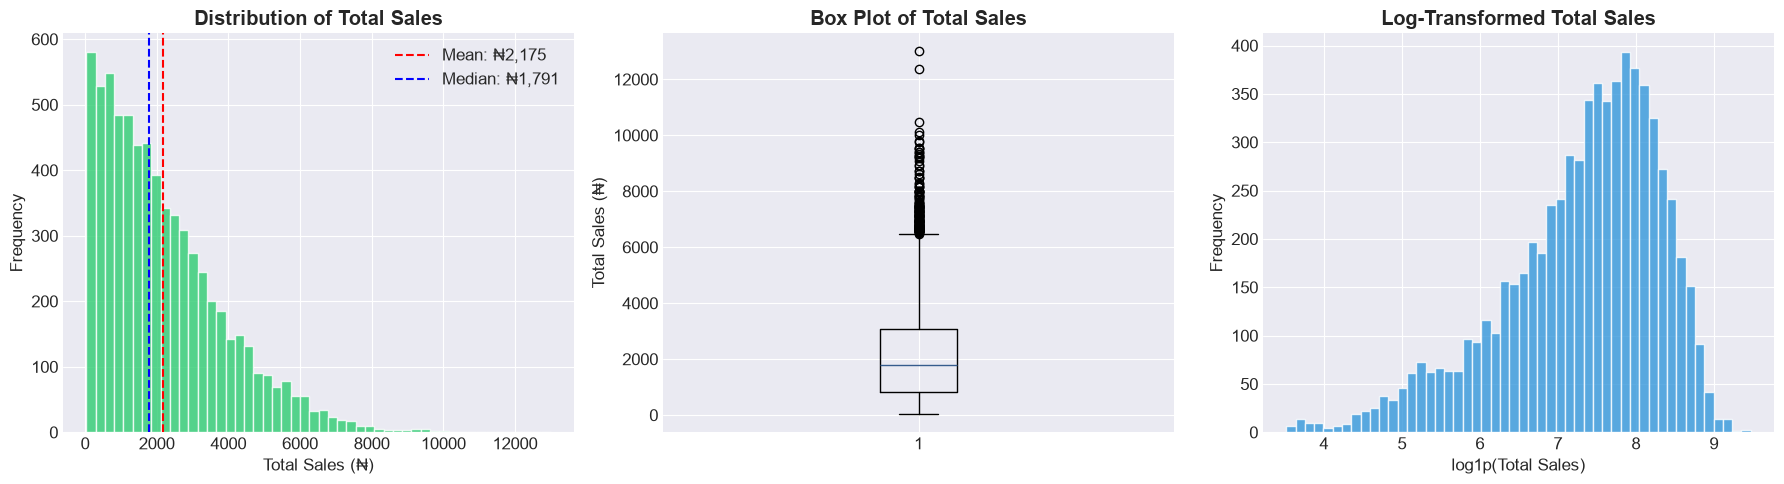


 Total Sales Statistics:
 Mean:  ₦2,174.76
 Median: ₦1,790.89
 Std Dev: ₦1,697.89
 Min:  ₦32.70
 Max:  ₦12,996.82
 Skewness: 1.15

 After log1p transform Skewness: -0.90


In [31]:
# --- TARGET DISTRIBUTION ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(train['total_sales'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0].axvline(train['total_sales'].mean(), color='red', linestyle='--', label=f"Mean: ₦{train['total_sales'].mean():,.0f}")
axes[0].axvline(train['total_sales'].median(), color='blue', linestyle='--', label=f"Median: ₦{train['total_sales'].median():,.0f}")
axes[0].set_title('Distribution of Total Sales', fontweight='bold')
axes[0].set_xlabel('Total Sales (₦)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(train['total_sales'], vert=True)
axes[1].set_title('Box Plot of Total Sales', fontweight='bold')
axes[1].set_ylabel('Total Sales (₦)')

# Log-transformed histogram
log_sales = np.log1p(train['total_sales'])
axes[2].hist(log_sales, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[2].set_title('Log-Transformed Total Sales', fontweight='bold')
axes[2].set_xlabel('log1p(Total Sales)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Statistics
print("\n Total Sales Statistics:")
print(f" Mean:  ₦{train['total_sales'].mean():,.2f}")
print(f" Median: ₦{train['total_sales'].median():,.2f}")
print(f" Std Dev: ₦{train['total_sales'].std():,.2f}")
print(f" Min:  ₦{train['total_sales'].min():,.2f}")
print(f" Max:  ₦{train['total_sales'].max():,.2f}")
print(f" Skewness: {train['total_sales'].skew():.2f}")
print(f"\n After log1p transform Skewness: {log_sales.skew():.2f}")

In [33]:
# --- THE HIDDEN TRAP: CATEGORY INCONSISTENCY ---
print(f"Number of unique product categories: {train['product_category'].nunique()}")
print(f"\nAll categories (notice the problem?):")
print("-" * 50)
for i, cat in enumerate(sorted(train['product_category'].unique()), 1):
 print(f" {i:2d}. '{cat}'")

Number of unique product categories: 48

All categories (notice the problem?):
--------------------------------------------------
  1. 'BAKING GOODS'
  2. 'BREADS'
  3. 'BREAKFAST'
  4. 'Baking Goods'
  5. 'Breads'
  6. 'Breakfast'
  7. 'CANNED'
  8. 'Canned'
  9. 'DAIRY'
 10. 'Dairy'
 11. 'FROZEN FOODS'
 12. 'FRUITS AND VEGETABLES'
 13. 'Frozen Foods'
 14. 'Fruits and Vegetables'
 15. 'HARD DRINKS'
 16. 'HEALTH AND HYGIENE'
 17. 'HOUSEHOLD'
 18. 'Hard Drinks'
 19. 'Health and Hygiene'
 20. 'Household'
 21. 'MEAT'
 22. 'Meat'
 23. 'OTHERS'
 24. 'Others'
 25. 'SEAFOOD'
 26. 'SNACK FOODS'
 27. 'SOFT DRINKS'
 28. 'STARCHY FOODS'
 29. 'Seafood'
 30. 'Snack Foods'
 31. 'Soft Drinks'
 32. 'Starchy Foods'
 33. 'baking goods'
 34. 'breads'
 35. 'breakfast'
 36. 'canned'
 37. 'dairy'
 38. 'frozen foods'
 39. 'fruits and vegetables'
 40. 'hard drinks'
 41. 'health and hygiene'
 42. 'household'
 43. 'meat'
 44. 'others'
 45. 'seafood'
 46. 'snack foods'
 47. 'soft drinks'
 48. 'starchy foods'


In [34]:
# Let's see what the 16 real categories are
real_categories = sorted(train['product_category'].str.lower().str.strip().unique())
print(f"After standardizing case {len(real_categories)} unique categories:\n")
for i, cat in enumerate(real_categories, 1):
 count = train[train['product_category'].str.lower().str.strip() == cat].shape[0]
 print(f" {i:2d}. {cat.title():<30} ({count:,} products)")

After standardizing case 16 unique categories:

  1. Baking Goods                   (516 products)
  2. Breads                         (209 products)
  3. Breakfast                      (85 products)
  4. Canned                         (517 products)
  5. Dairy                          (554 products)
  6. Frozen Foods                   (675 products)
  7. Fruits And Vegetables          (1,006 products)
  8. Hard Drinks                    (169 products)
  9. Health And Hygiene             (412 products)
 10. Household                      (740 products)
 11. Meat                           (339 products)
 12. Others                         (132 products)
 13. Seafood                        (52 products)
 14. Snack Foods                    (933 products)
 15. Soft Drinks                    (366 products)
 16. Starchy Foods                  (113 products)


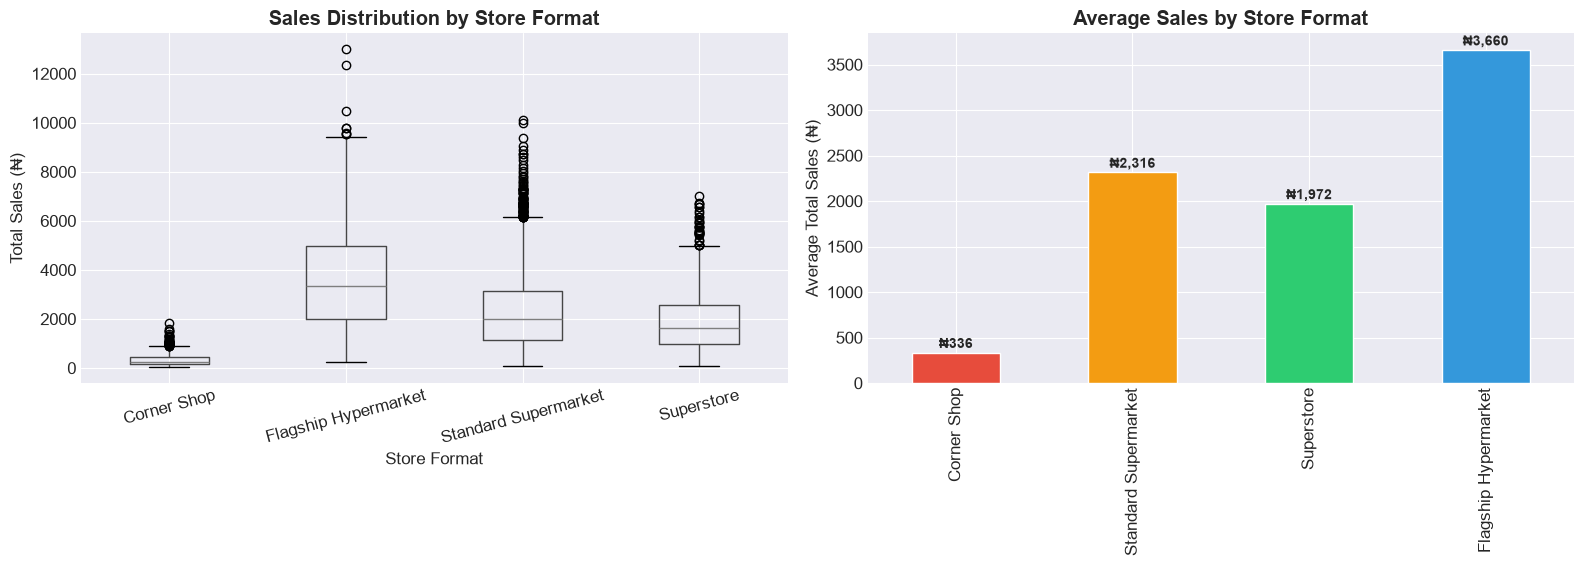


 Average Sales by Store Format:
 Corner Shop                    ₦336.35 (866 records)
 Standard Supermarket           ₦2,316.32 (4,462 records)
 Superstore                     ₦1,971.66 (742 records)
 Flagship Hypermarket           ₦3,660.18 (748 records)


In [35]:
# --- SALES BY STORE FORMAT ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
store_format_order = ['Corner Shop', 'Standard Supermarket', 'Superstore', 'Flagship Hypermarket']
train.boxplot(column='total_sales', by='store_format', ax=axes[0])
axes[0].set_title('Sales Distribution by Store Format', fontweight='bold')
axes[0].set_xlabel('Store Format')
axes[0].set_ylabel('Total Sales (₦)')
plt.sca(axes[0])
plt.xticks(rotation=15)

# Bar plot of means
store_means = train.groupby('store_format')['total_sales'].mean().reindex(store_format_order)
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
store_means.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Average Sales by Store Format', fontweight='bold')
axes[1].set_ylabel('Average Total Sales (₦)')
axes[1].set_xlabel('')
plt.xticks(rotation=15)

# Add value labels on bars
for i, v in enumerate(store_means.values):
 axes[1].text(i, v + 50, f'₦{v:,.0f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('') # Remove auto-generated title
plt.tight_layout()
plt.show()

print("\n Average Sales by Store Format:")
for fmt in store_format_order:
 mean_sales = train[train['store_format'] == fmt]['total_sales'].mean()
 count = train[train['store_format'] == fmt].shape[0]
 print(f" {fmt:<30} ₦{mean_sales:,.2f} ({count:,} records)")

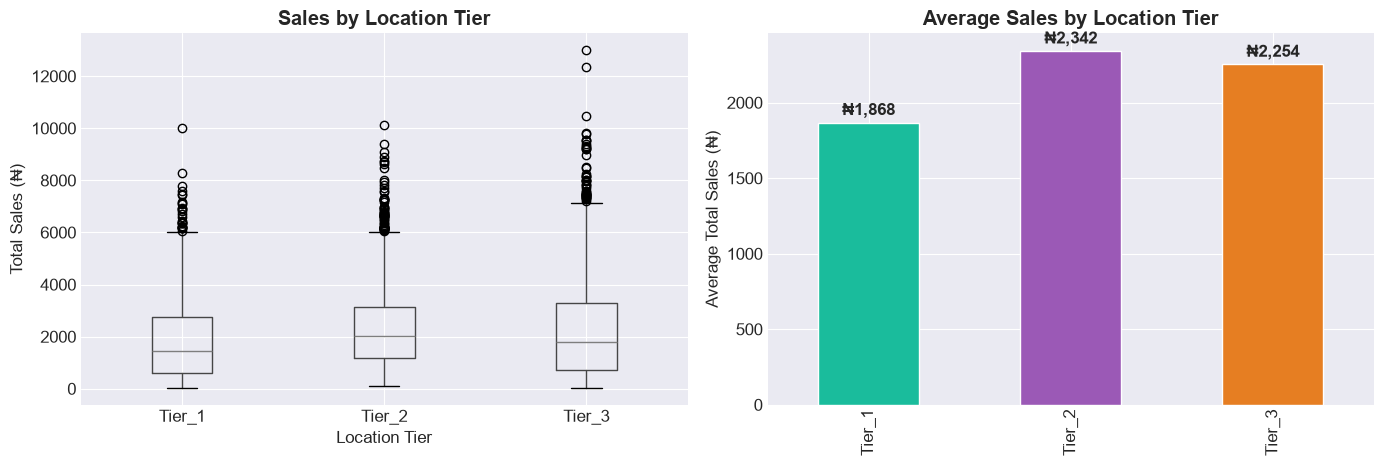


Tier Descriptions:
 Tier 1 = Major urban centers (Lagos, Abuja)
 Tier 2 = State capitals
 Tier 3 = Smaller towns


In [36]:
# --- SALES BY LOCATION TIER ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_order = ['Tier_1', 'Tier_2', 'Tier_3']
tier_means = train.groupby('store_location_tier')['total_sales'].mean().reindex(tier_order)

# Box plot
train.boxplot(column='total_sales', by='store_location_tier', ax=axes[0])
axes[0].set_title('Sales by Location Tier', fontweight='bold')
axes[0].set_xlabel('Location Tier')
axes[0].set_ylabel('Total Sales (₦)')

# Bar plot
colors = ['#1abc9c', '#9b59b6', '#e67e22']
tier_means.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Average Sales by Location Tier', fontweight='bold')
axes[1].set_ylabel('Average Total Sales (₦)')
axes[1].set_xlabel('')

for i, v in enumerate(tier_means.values):
 axes[1].text(i, v + 50, f'₦{v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("\nTier Descriptions:")
print(" Tier 1 = Major urban centers (Lagos, Abuja)")
print(" Tier 2 = State capitals")
print(" Tier 3 = Smaller towns")

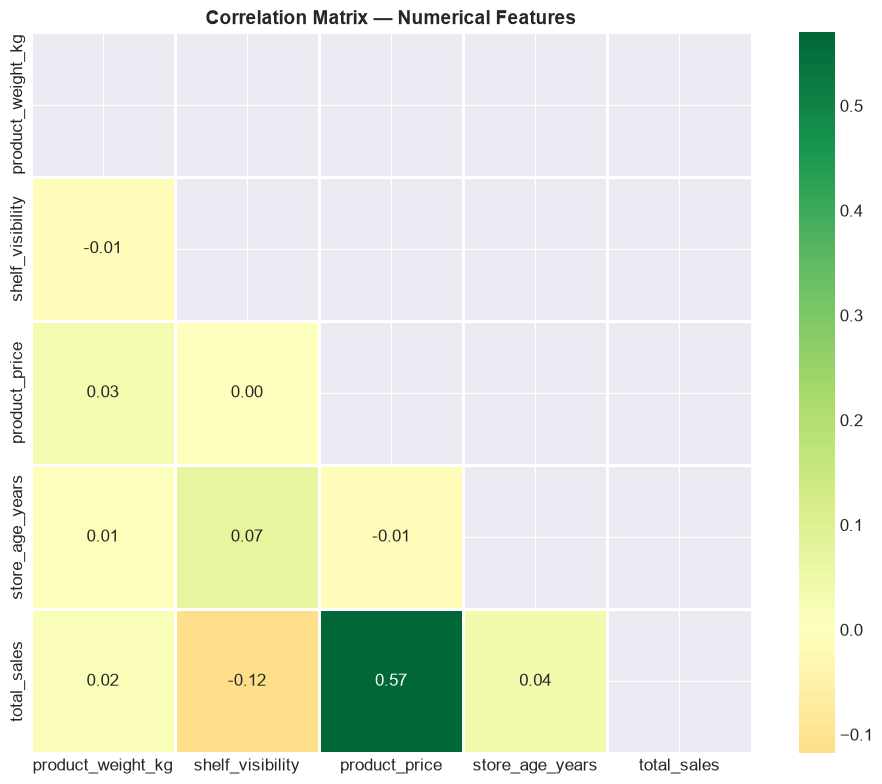


 Correlation with total_sales:
----------------------------------------
 product_price             +0.570 
 store_age_years           +0.039 
 product_weight_kg         +0.016 
 shelf_visibility          -0.118 


In [37]:
#CORELATION ANALYSIS
# --- CORRELATION HEATMAP ---
# Select only numerical columns
numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train[numerical_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
   center=0, square=True, linewidths=1, linecolor='white')
plt.title('Correlation Matrix — Numerical Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Show correlations with target
print("\n Correlation with total_sales:")
print("-" * 40)
target_corr = corr_matrix['total_sales'].drop('total_sales').sort_values(ascending=False)
for col, corr in target_corr.items():
 bar = '' * int(abs(corr) * 30)
 sign = '+' if corr > 0 else '-'
 print(f" {col:<25} {sign}{abs(corr):.3f} {bar}")

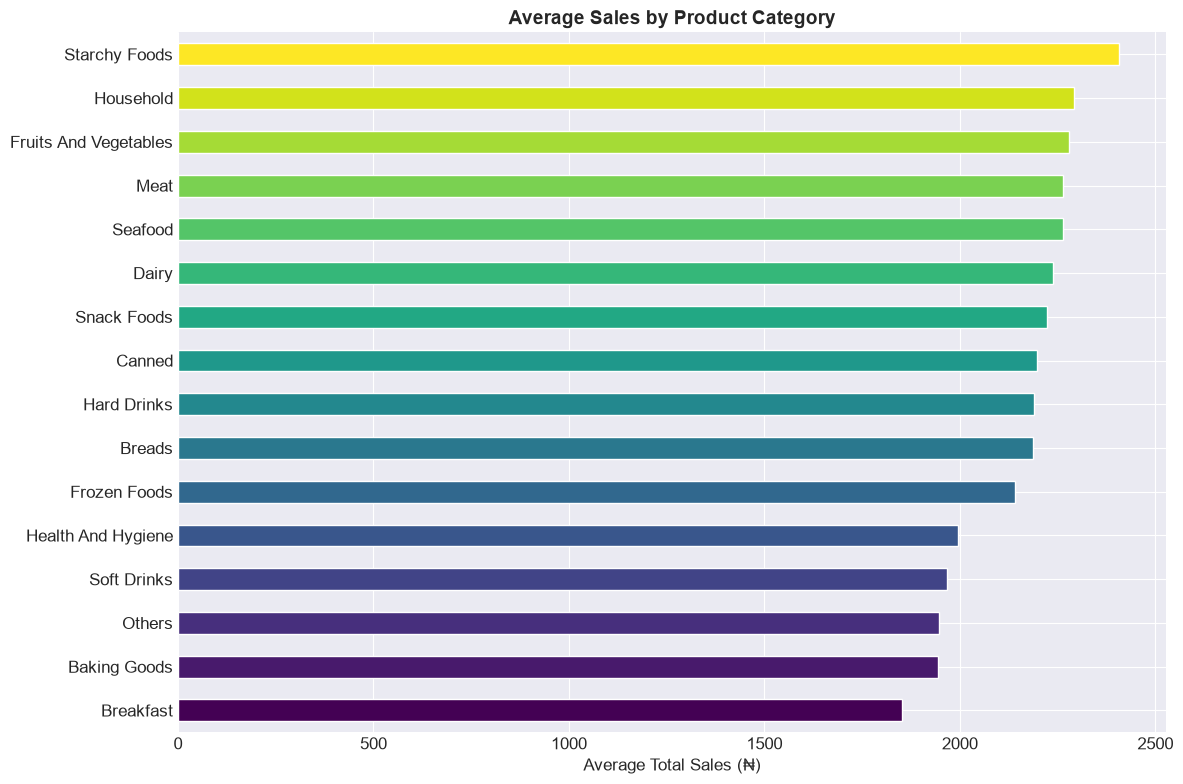

In [38]:
# --- SALES BY PRODUCT CATEGORY ---
# Standardize category first (preview of Section 3)
train_temp = train.copy()
train_temp['product_category_clean'] = train_temp['product_category'].str.lower().str.strip().str.title()

cat_means = train_temp.groupby('product_category_clean')['total_sales'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
cat_means.plot(kind='barh', color=plt.cm.viridis(np.linspace(0, 1, len(cat_means))), edgecolor='white')
plt.title('Average Sales by Product Category', fontweight='bold', fontsize=14)
plt.xlabel('Average Total Sales (₦)')
plt.ylabel('')
plt.tight_layout()
plt.show()

del train_temp # Clean up

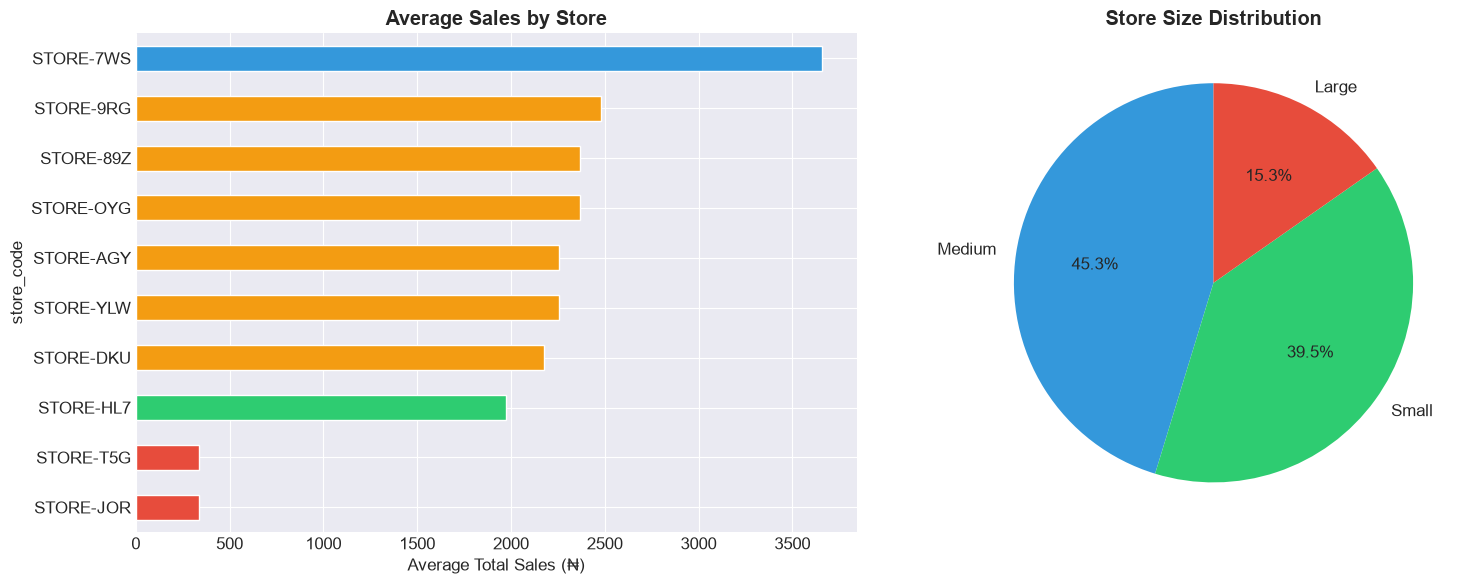


 Store Details:
Store           Format                    Size       Tier       Avg Sales       Count
------------------------------------------------------------------------------------------
STORE-JOR       Corner Shop               MISSING    Tier_3     ₦    334.44   439
STORE-T5G       Corner Shop               Small      Tier_1     ₦    338.33   427
STORE-HL7       Superstore                Medium     Tier_3     ₦  1,971.66   742
STORE-DKU       Standard Supermarket      MISSING    Tier_2     ₦  2,177.14   736
STORE-YLW       Standard Supermarket      Small      Tier_1     ₦  2,253.95   754
STORE-AGY       Standard Supermarket      Large      Tier_3     ₦  2,254.89   748
STORE-OYG       Standard Supermarket      MISSING    Tier_2     ₦  2,365.83   744
STORE-89Z       Standard Supermarket      Medium     Tier_1     ₦  2,365.93   728
STORE-9RG       Standard Supermarket      Small      Tier_2     ₦  2,479.17   752
STORE-7WS       Flagship Hypermarket      Medium     Tier_3     ₦  3

In [39]:
# --- SALES BY STORE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by store
store_stats = train.groupby('store_code').agg(
 mean_sales=('total_sales', 'mean'),
 count=('total_sales', 'count'),
 store_format=('store_format', 'first'),
 store_size=('store_size', 'first'),
 store_tier=('store_location_tier', 'first')
).sort_values('mean_sales', ascending=True)

colors_map = {
 'Corner Shop': '#e74c3c', 'Standard Supermarket': '#f39c12',
 'Superstore': '#2ecc71', 'Flagship Hypermarket': '#3498db'
}
bar_colors = [colors_map.get(fmt, '#95a5a6') for fmt in store_stats['store_format']]

store_stats['mean_sales'].plot(kind='barh', ax=axes[0], color=bar_colors, edgecolor='white')
axes[0].set_title('Average Sales by Store', fontweight='bold')
axes[0].set_xlabel('Average Total Sales (₦)')

# Store size distribution
store_size_counts = train['store_size'].value_counts()
store_size_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
      colors=['#3498db', '#2ecc71', '#e74c3c'],
      startangle=90)
axes[1].set_title('Store Size Distribution', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n Store Details:")
print(f"{'Store':<15} {'Format':<25} {'Size':<10} {'Tier':<10} {'Avg Sales':<15} {'Count'}")
print("-" * 90)
for store, row in store_stats.iterrows():
 size = row['store_size'] if pd.notna(row['store_size']) else 'MISSING'
 print(f"{store:<15} {row['store_format']:<25} {size:<10} {row['store_tier']:<10} ₦{row['mean_sales']:>10,.2f} {row['count']:>5,}")

Data Cleaning & Preprocessing

In [43]:
# --- FIX 1: STANDARDIZE PRODUCT CATEGORY ---
# WHY: "Frozen Foods", "frozen foods", and "FROZEN FOODS" are the same thing.
#  By standardizing to title case, we go from 48 16 categories.

# HOW: .str.lower() converts everything to lowercase first,
#  .str.strip() removes leading/trailing spaces,
#  .str.title() capitalizes the first letter of each word.

print("BEFORE cleaning:")
print(f" Train categories: {train['product_category'].nunique()}")
print(f" Test categories: {test['product_category'].nunique()}")

# Apply to BOTH train and test (always transform both!)
train['product_category'] = train['product_category'].str.lower().str.strip().str.title()
test['product_category'] = test['product_category'].str.lower().str.strip().str.title()

print("\nAFTER cleaning:")
print(f" Train categories: {train['product_category'].nunique()}")
print(f" Test categories: {test['product_category'].nunique()}")
print(f"\n Categories standardized! 48 {train['product_category'].nunique()} real categories")
print(f"\nClean categories:")
for i, cat in enumerate(sorted(train['product_category'].unique()), 1):
 print(f" {i:2d}. {cat}")

BEFORE cleaning:
 Train categories: 16
 Test categories: 16

AFTER cleaning:
 Train categories: 16
 Test categories: 16

 Categories standardized! 48 16 real categories

Clean categories:
  1. Baking Goods
  2. Breads
  3. Breakfast
  4. Canned
  5. Dairy
  6. Frozen Foods
  7. Fruits And Vegetables
  8. Hard Drinks
  9. Health And Hygiene
 10. Household
 11. Meat
 12. Others
 13. Seafood
 14. Snack Foods
 15. Soft Drinks
 16. Starchy Foods


In [44]:
# --- FILL MISSING STORE SIZE ---
# WHY: store_size is missing for ~28% of rows, but each store
#  has a FIXED size. We just need to look it up.
#
# HOW: Create a mapping of store_code store_size from rows
#  where we DO have the size, then fill the gaps.

# Step 1: Find the known mapping
print("Step 1: Find store_code store_size mapping from known values")
store_size_map = train.dropna(subset=['store_size']).groupby('store_code')['store_size'].first()
print(store_size_map)

# Step 2: Fill missing values in BOTH train and test
print(f"\nStep 2: Fill missing values")
print(f" Missing BEFORE — Train: {train['store_size'].isna().sum()}, Test: {test['store_size'].isna().sum()}")

train['store_size'] = train['store_code'].map(store_size_map).fillna(train['store_size'])
test['store_size'] = test['store_code'].map(store_size_map).fillna(test['store_size'])

print(f" Missing AFTER — Train: {train['store_size'].isna().sum()}, Test: {test['store_size'].isna().sum()}")

# If any still missing, fill with mode (most common)
if train['store_size'].isna().sum() > 0:
 mode_size = train['store_size'].mode()[0]
 train['store_size'].fillna(mode_size, inplace=True)
 test['store_size'].fillna(mode_size, inplace=True)
 print(f" Remaining filled with mode: '{mode_size}'")

print("\n store_size completely filled!")

Step 1: Find store_code store_size mapping from known values
store_code
STORE-7WS    Medium
STORE-89Z    Medium
STORE-9RG     Small
STORE-AGY     Large
STORE-HL7    Medium
STORE-T5G     Small
STORE-YLW     Small
Name: store_size, dtype: object

Step 2: Fill missing values
 Missing BEFORE — Train: 1919, Test: 491
 Missing AFTER — Train: 1919, Test: 491
 Remaining filled with mode: 'Medium'

 store_size completely filled!


In [45]:
# --- FIX 3: FILL MISSING PRODUCT WEIGHT ---
# WHY: product_weight_kg is missing for ~18% of rows
# HOW: Fill with the MEDIAN weight of products in the same category
#
# Why MEDIAN not MEAN? Median is robust to outliers.
# If one product weighs 100kg, the mean gets pulled up, but median stays stable.

print(f"Missing weight BEFORE — Train: {train['product_weight_kg'].isna().sum()}, Test: {test['product_weight_kg'].isna().sum()}")

# Calculate median weight per category
category_weight_median = train.groupby('product_category')['product_weight_kg'].median()
print("\nMedian weight by category:")
for cat, weight in category_weight_median.sort_values().items():
 print(f" {cat:<30} {weight:.2f} kg")

# Fill missing weights using category median
for cat in train['product_category'].unique():
 median_weight = category_weight_median.get(cat, train['product_weight_kg'].median())

 train.loc[(train['product_category'] == cat) & (train['product_weight_kg'].isna()),
    'product_weight_kg'] = median_weight

 test.loc[(test['product_category'] == cat) & (test['product_weight_kg'].isna()),
    'product_weight_kg'] = median_weight

# Catch any remaining NAs with overall median
overall_median = train['product_weight_kg'].median()
train['product_weight_kg'].fillna(overall_median, inplace=True)
test['product_weight_kg'].fillna(overall_median, inplace=True)

print(f"\nMissing weight AFTER — Train: {train['product_weight_kg'].isna().sum()}, Test: {test['product_weight_kg'].isna().sum()}")
print("\n product_weight_kg completely filled!")

Missing weight BEFORE — Train: 1225, Test: 306

Median weight by category:
 Hard Drinks                    9.57 kg
 Breads                         10.56 kg
 Breakfast                      10.99 kg
 Baking Goods                   11.50 kg
 Soft Drinks                    11.57 kg
 Seafood                        11.81 kg
 Health And Hygiene             12.06 kg
 Canned                         12.24 kg
 Meat                           12.38 kg
 Frozen Foods                   12.81 kg
 Snack Foods                    13.08 kg
 Fruits And Vegetables          13.09 kg
 Starchy Foods                  13.19 kg
 Dairy                          13.36 kg
 Household                      13.37 kg
 Others                         14.55 kg

Missing weight AFTER — Train: 0, Test: 0

 product_weight_kg completely filled!


In [46]:
# --- ENCODE CATEGORICAL FEATURES ---
# WHY: Models need numbers, not text
# HOW: LabelEncoder maps each unique text to an integer

categorical_cols = ['fat_content', 'product_category', 'store_code',
     'store_size', 'store_location_tier', 'store_format']

label_encoders = {} # Save these — we'll need them later!

print("Label Encoding categorical features:")
print("-" * 60)
for col in categorical_cols:
 le = LabelEncoder()
 # Fit on COMBINED train+test to ensure consistent encoding
 combined = pd.concat([train[col], test[col]], axis=0)
 le.fit(combined)

 train[col + '_encoded'] = le.transform(train[col])
 test[col + '_encoded'] = le.transform(test[col])
 label_encoders[col] = le

 print(f" {col:<25} {len(le.classes_)} unique values")
 for cls, code_val in zip(le.classes_[:5], le.transform(le.classes_[:5])):
  print(f"  '{cls}' {code_val}")
 if len(le.classes_) > 5:
  print(f"  ... and {len(le.classes_)-5} more")

print("\n All categorical features encoded!")

Label Encoding categorical features:
------------------------------------------------------------
 fat_content               2 unique values
  'Low Fat' 0
  'Regular' 1
 product_category          16 unique values
  'Baking Goods' 0
  'Breads' 1
  'Breakfast' 2
  'Canned' 3
  'Dairy' 4
  ... and 11 more
 store_code                10 unique values
  'STORE-7WS' 0
  'STORE-89Z' 1
  'STORE-9RG' 2
  'STORE-AGY' 3
  'STORE-DKU' 4
  ... and 5 more
 store_size                3 unique values
  'Large' 0
  'Medium' 1
  'Small' 2
 store_location_tier       3 unique values
  'Tier_1' 0
  'Tier_2' 1
  'Tier_3' 2
 store_format              4 unique values
  'Corner Shop' 0
  'Flagship Hypermarket' 1
  'Standard Supermarket' 2
  'Superstore' 3

 All categorical features encoded!


In [47]:
# --- FINAL CHECK: NO MISSING VALUES ---
print("Missing values after all cleaning:")
print("\nTRAIN:")
missing_train = train.isnull().sum()
print(missing_train[missing_train > 0] if missing_train.sum() > 0 else " No missing values!")

print("\nTEST:")
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0] if missing_test.sum() > 0 else " No missing values!")

print(f"\n Final dataset shapes:")
print(f" Train: {train.shape}")
print(f" Test: {test.shape}")

Missing values after all cleaning:

TRAIN:
 No missing values!

TEST:
 No missing values!

 Final dataset shapes:
 Train: (6818, 19)
 Test: (1705, 18)


In [ ]:
FEATURE ENGINEERING

In [48]:
# - FEATURE ENGINEERING -

def engineer_features(df):
 '''
 Create new features from existing columns.
 Apply this to BOTH train and test to keep them consistent.

 '''
 df = df.copy()

 # --- PRODUCT FEATURES ---

 # Price per kg: expensive-per-unit items might have different sales patterns
 # WHY: A ₦200 product that weighs 2kg is different from one weighing 20kg
 df['price_per_kg'] = df['product_price'] / (df['product_weight_kg'] + 0.01)

 # Price range indicator: is this a cheap, mid, or expensive product?
 # WHY: Budget products might have higher volume but lower per-unit sales
 df['price_bin'] = pd.qcut(df['product_price'], q=5, labels=False, duplicates='drop')

 # Weight category: light, medium, heavy
 # WHY: Heavy items might be bought less frequently
 df['weight_bin'] = pd.qcut(df['product_weight_kg'], q=4, labels=False, duplicates='drop')

 # --- SHELF VISIBILITY FEATURES ---

 # Visibility Price interaction
 # A highly visible expensive product might sell differently than
 #  a highly visible cheap product
 df['visibility_x_price'] = df['shelf_visibility'] * df['product_price']

 # Is the product hidden? (very low visibility)
 # WHY: Products with 0 visibility might be special cases
 df['is_low_visibility'] = (df['shelf_visibility'] < 0.02).astype(int)

 # --- STORE FEATURES ---

 # Store age bins
 # Brand new stores vs established ones may have different patterns
 df['store_age_bin'] = pd.cut(df['store_age_years'], bins=[0, 25, 30, 40, 50],
         labels=[0, 1, 2, 3]).astype(int)

 # --- INTERACTION FEATURES ---

 # These combine information from two columns into one.
 # Tree models CAN discover interactions, but making them explicit helps.

 # Product price store format (encoded)
 # A ₦200 product in a Corner Shop vs a Hypermarket likely sells differently
 df['price_x_format'] = df['product_price'] * df['store_format_encoded']

 # Weight visibility
 # WHY: Heavy + visible products might be promoted items
 df['weight_x_visibility'] = df['product_weight_kg'] * df['shelf_visibility']

 return df

# Apply to both datasets
train = engineer_features(train)
test = engineer_features(test)

print(" Feature engineering complete!")
print(f"\nTrain columns: {train.shape[1]} (was 13 now {train.shape[1]})")
print(f"Test columns: {test.shape[1]}")

# Show new features
new_features = ['price_per_kg', 'price_bin', 'weight_bin', 'visibility_x_price',
    'is_low_visibility', 'store_age_bin', 'price_x_format', 'weight_x_visibility']
print(f"\n New features created:")
for f in new_features:
 print(f"  {f}")

 Feature engineering complete!

Train columns: 27 (was 13 now 27)
Test columns: 26

 New features created:
  price_per_kg
  price_bin
  weight_bin
  visibility_x_price
  is_low_visibility
  store_age_bin
  price_x_format
  weight_x_visibility


In [49]:
# --- TARGET ENCODING: Store-level and Category-level statistics ---
#  Some stores consistently sell more than others.
#  Encoding this gives the model a "baseline" for each store.

# Store-level mean sales
store_mean_sales = train.groupby('store_code')['total_sales'].mean()
train['store_mean_sales'] = train['store_code'].map(store_mean_sales)
test['store_mean_sales'] = test['store_code'].map(store_mean_sales)

# Store-level median sales (more robust to outliers)
store_median_sales = train.groupby('store_code')['total_sales'].median()
train['store_median_sales'] = train['store_code'].map(store_median_sales)
test['store_median_sales'] = test['store_code'].map(store_median_sales)

# Category-level mean sales
cat_mean_sales = train.groupby('product_category')['total_sales'].mean()
train['category_mean_sales'] = train['product_category'].map(cat_mean_sales)
test['category_mean_sales'] = test['product_category'].map(cat_mean_sales)

# Fill any NAs (categories in test not in train)
for col in ['store_mean_sales', 'store_median_sales', 'category_mean_sales']:
 train[col].fillna(train['total_sales'].mean(), inplace=True)
 test[col].fillna(train['total_sales'].mean(), inplace=True)

print(" Target encoding complete!")
print(f"\nStore mean sales:")
for store, mean_val in store_mean_sales.sort_values(ascending=False).items():
 print(f" {store}: ₦{mean_val:,.2f}")

 Target encoding complete!

Store mean sales:
 STORE-7WS: ₦3,660.18
 STORE-9RG: ₦2,479.17
 STORE-89Z: ₦2,365.93
 STORE-OYG: ₦2,365.83
 STORE-AGY: ₦2,254.89
 STORE-YLW: ₦2,253.95
 STORE-DKU: ₦2,177.14
 STORE-HL7: ₦1,971.66
 STORE-T5G: ₦338.33
 STORE-JOR: ₦334.44


In [50]:
# --- PREPARE FEATURES FOR MODELING ---
# We select only the features our model will use.
# We EXCLUDE: id, product_code (just identifiers), original text columns,
#    and the target (total_sales).

feature_cols = [
 # Original numerical features
 'product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years',

 # Encoded categorical features
 'fat_content_encoded', 'product_category_encoded', 'store_code_encoded',
 'store_size_encoded', 'store_location_tier_encoded', 'store_format_encoded',

 # Engineered features
 'price_per_kg', 'price_bin', 'weight_bin',
 'visibility_x_price', 'is_low_visibility', 'store_age_bin',
 'price_x_format', 'weight_x_visibility',

 # Target-encoded features
 'store_mean_sales', 'store_median_sales', 'category_mean_sales',
]

X = train[feature_cols]
y = train['total_sales']
X_test_final = test[feature_cols]

print(f" Features prepared!")
print(f" Training features: {X.shape}")
print(f" Test features:  {X_test_final.shape}")
print(f" Target:   {y.shape}")
print(f"\n Feature list ({len(feature_cols)} features):")
for i, col in enumerate(feature_cols, 1):
 print(f" {i:2d}. {col}")

 Features prepared!
 Training features: (6818, 21)
 Test features:  (1705, 21)
 Target:   (6818,)

 Feature list (21 features):
  1. product_weight_kg
  2. shelf_visibility
  3. product_price
  4. store_age_years
  5. fat_content_encoded
  6. product_category_encoded
  7. store_code_encoded
  8. store_size_encoded
  9. store_location_tier_encoded
 10. store_format_encoded
 11. price_per_kg
 12. price_bin
 13. weight_bin
 14. visibility_x_price
 15. is_low_visibility
 16. store_age_bin
 17. price_x_format
 18. weight_x_visibility
 19. store_mean_sales
 20. store_median_sales
 21. category_mean_sales


In [51]:
# --- BASELINE 1: PREDICT THE MEAN ---
# WHY: This is the absolute floor. Any model that can't beat this is useless.

mean_prediction = y.mean()
mean_predictions = np.full(len(y), mean_prediction)
baseline_rmse = root_mean_squared_error(y, mean_predictions)

print(f" Baseline Model: Predict Mean")
print(f" Predicted value for everything: ₦{mean_prediction:,.2f}")
print(f" RMSE: {baseline_rmse:,.2f}")
print(f"\n This means: on average, this 'model' is off by ₦{baseline_rmse:,.2f} per prediction")
print(f"\n Our goal: beat {baseline_rmse:,.2f} RMSE (and go as low as possible!)")

 Baseline Model: Predict Mean
 Predicted value for everything: ₦2,174.76
 RMSE: 1,697.77

 This means: on average, this 'model' is off by ₦1,697.77 per prediction

 Our goal: beat 1,697.77 RMSE (and go as low as possible!)


In [52]:
# --- BASELINE 2: LINEAR REGRESSION ---
# WHY: A simple model that assumes linear relationships.
#  If it beats the mean, our features contain useful information.

from sklearn.model_selection import cross_val_score

lr = LinearRegression()
lr_scores = cross_val_score(lr, X, y, cv=5, scoring='neg_root_mean_squared_error')
lr_rmse = -lr_scores.mean()

print(f" Linear Regression (5-Fold Cross-Validation)")
print(f" RMSE per fold: {[-s for s in lr_scores]}")
print(f" Average RMSE: {lr_rmse:,.2f}")
print(f" Improvement over mean baseline: {baseline_rmse - lr_rmse:,.2f} ( lower is better)")

 Linear Regression (5-Fold Cross-Validation)
 RMSE per fold: [np.float64(1061.1343443639985), np.float64(1094.7906795659346), np.float64(1117.302270142865), np.float64(1160.4124182610726), np.float64(1134.5378103253995)]
 Average RMSE: 1,113.64
 Improvement over mean baseline: 584.13 ( lower is better)


In [53]:
# --- BASELINE 3: DECISION TREE ---
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_scores = cross_val_score(dt, X, y, cv=5, scoring='neg_root_mean_squared_error')
dt_rmse = -dt_scores.mean()

print(f" Decision Tree (5-Fold CV, max_depth=10)")
print(f" Average RMSE: {dt_rmse:,.2f}")
print(f" vs Mean baseline: {' Better' if dt_rmse < baseline_rmse else ' Worse'} ( {baseline_rmse - dt_rmse:,.2f})")
print(f" vs Linear Reg: {' Better' if dt_rmse < lr_rmse else ' Worse'} ( {lr_rmse - dt_rmse:,.2f})")

 Decision Tree (5-Fold CV, max_depth=10)
 Average RMSE: 1,245.26
 vs Mean baseline:  Better ( 452.51)
 vs Linear Reg:  Worse ( -131.62)


In [54]:
# --- BASELINE RESULTS COMPARISON ---
results = {
 'Model': ['Mean Baseline', 'Linear Regression', 'Decision Tree'],
 'RMSE': [baseline_rmse, lr_rmse, dt_rmse],
}
results_df = pd.DataFrame(results).sort_values('RMSE')

print(" BASELINE RESULTS")
print("=" * 50)
for _, row in results_df.iterrows():
 bar = '' * int(row['RMSE'] / 50)
 print(f" {row['Model']:<25} RMSE: {row['RMSE']:>10,.2f} {bar}")

print(f"\n Best baseline: {results_df.iloc[0]['Model']} with RMSE {results_df.iloc[0]['RMSE']:,.2f}")
print(f"\n Now let's see how much better we can do with advanced models! ")

 BASELINE RESULTS
 Linear Regression         RMSE:   1,113.64 
 Decision Tree             RMSE:   1,245.26 
 Mean Baseline             RMSE:   1,697.77 

 Best baseline: Linear Regression with RMSE 1,113.64

 Now let's see how much better we can do with advanced models! 


In [55]:
# --- RANDOM FOREST ---
rf = RandomForestRegressor(
 n_estimators=200,  # Number of trees
 max_depth=15,   # How deep each tree goes
 min_samples_leaf=5, # Minimum samples per leaf
 random_state=42,
 n_jobs=-1    # Use all CPU cores
)

rf_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_root_mean_squared_error')
rf_rmse = -rf_scores.mean()

print(f" Random Forest (200 trees, 5-Fold CV)")
print(f" RMSE per fold: {[-round(s, 2) for s in rf_scores]}")
print(f" Average RMSE: {rf_rmse:,.2f}")

 Random Forest (200 trees, 5-Fold CV)
 RMSE per fold: [np.float64(1044.8), np.float64(1077.44), np.float64(1108.29), np.float64(1138.01), np.float64(1117.01)]
 Average RMSE: 1,097.11


In [56]:
# --- XGBOOST ---
xgb_model = xgb.XGBRegressor(
 n_estimators=1000,
 learning_rate=0.05,
 max_depth=7,
 subsample=0.8,
 colsample_bytree=0.8,
 min_child_weight=5,
 reg_alpha=1.0,
 reg_lambda=2.0,
 random_state=42,
 n_jobs=-1,
 tree_method='hist',  # Fast histogram-based method
 early_stopping_rounds=50, # Stop if no improvement for 50 rounds
)

# Train with cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_rmse_list = []
xgb_test_preds = np.zeros(len(X_test_final))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
 X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
 y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

 xgb_model.fit(
  X_train, y_train,
  eval_set=[(X_val, y_val)],
  verbose=False
 )

 val_preds = xgb_model.predict(X_val)
 fold_rmse = root_mean_squared_error(y_val, val_preds)
 xgb_rmse_list.append(fold_rmse)

 # Accumulate test predictions (average across folds)
 xgb_test_preds += xgb_model.predict(X_test_final) / kf.n_splits

 print(f" Fold {fold+1}: RMSE = {fold_rmse:,.2f}")

xgb_rmse = np.mean(xgb_rmse_list)
print(f"\n XGBoost Average RMSE: {xgb_rmse:,.2f}")

 Fold 1: RMSE = 1,097.29
 Fold 2: RMSE = 1,065.76
 Fold 3: RMSE = 1,102.43
 Fold 4: RMSE = 1,129.38
 Fold 5: RMSE = 1,083.74

 XGBoost Average RMSE: 1,095.72


In [57]:
# --- LIGHTGBM ---
lgb_model = lgb.LGBMRegressor(
 n_estimators=1000,
 learning_rate=0.05,
 max_depth=7,
 num_leaves=63,   # Controls tree complexity
 subsample=0.8,
 colsample_bytree=0.8,
 min_child_samples=10,
 reg_alpha=1.0,
 reg_lambda=2.0,
 random_state=42,
 n_jobs=-1,
 verbose=-1,    # Suppress output
)

lgb_rmse_list = []
lgb_test_preds = np.zeros(len(X_test_final))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
 X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
 y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

 lgb_model.fit(
  X_train, y_train,
  eval_set=[(X_val, y_val)],
 )

 val_preds = lgb_model.predict(X_val)
 fold_rmse = root_mean_squared_error(y_val, val_preds)
 lgb_rmse_list.append(fold_rmse)

 lgb_test_preds += lgb_model.predict(X_test_final) / kf.n_splits

 print(f" Fold {fold+1}: RMSE = {fold_rmse:,.2f}")

lgb_rmse = np.mean(lgb_rmse_list)
print(f"\n LightGBM Average RMSE: {lgb_rmse:,.2f}")

 Fold 1: RMSE = 1,186.50
 Fold 2: RMSE = 1,135.22
 Fold 3: RMSE = 1,186.94
 Fold 4: RMSE = 1,205.90
 Fold 5: RMSE = 1,175.61

 LightGBM Average RMSE: 1,178.03


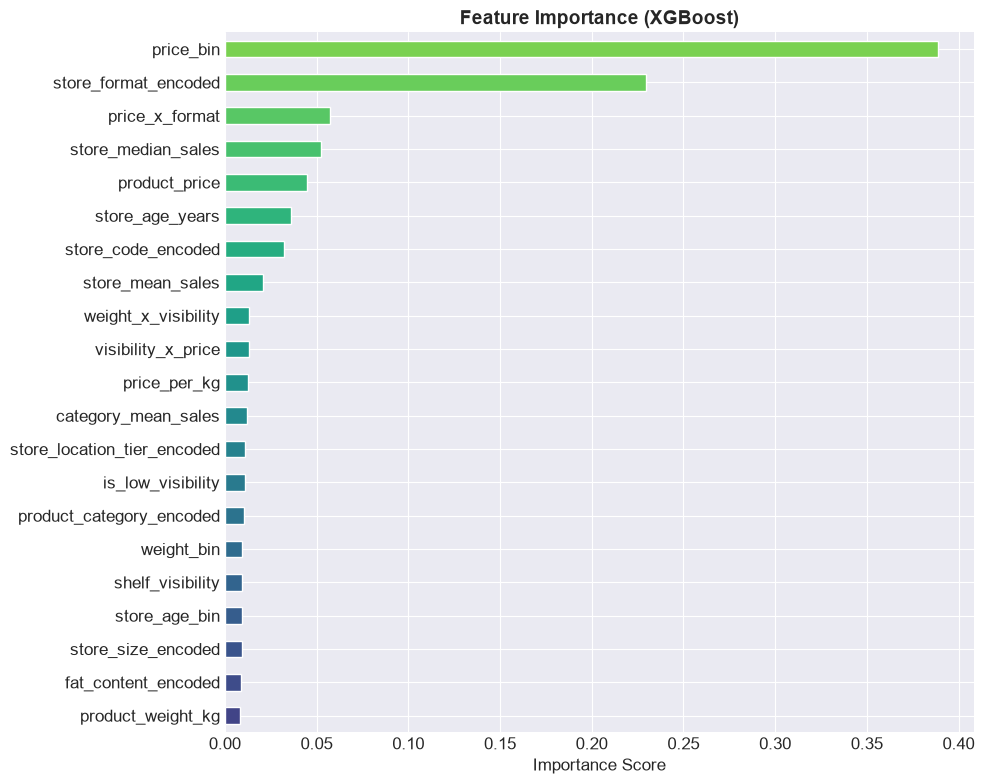


 Top 5 most important features:
 1. price_bin: 0.3888
 2. store_format_encoded: 0.2298
 3. price_x_format: 0.0576
 4. store_median_sales: 0.0526
 5. product_price: 0.0447


In [58]:
# --- FEATURE IMPORTANCE ---
# Train a final XGBoost model on all data to get importance
xgb_full = xgb.XGBRegressor(
 n_estimators=500, learning_rate=0.05, max_depth=7,
 subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_full.fit(X, y, verbose=False)

# Get feature importance
importance = pd.Series(xgb_full.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance.plot(kind='barh', color=plt.cm.viridis(np.linspace(0.2, 0.8, len(importance))),
    edgecolor='white')
plt.title('Feature Importance (XGBoost)', fontweight='bold', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n Top 5 most important features:")
for i, (feat, imp) in enumerate(importance.sort_values(ascending=False).head().items(), 1):
 print(f" {i}. {feat}: {imp:.4f}")

In [59]:
# --- HYPERPARAMETER TUNING WITH OPTUNA ---
try:
 import optuna
 optuna.logging.set_verbosity(optuna.logging.WARNING)
 OPTUNA_AVAILABLE = True
except ImportError:
 print(" Optuna not installed. Installing now...")
 import subprocess
 subprocess.check_call(['pip', 'install', 'optuna', '-q'])
 import optuna
 optuna.logging.set_verbosity(optuna.logging.WARNING)
 OPTUNA_AVAILABLE = True

def objective(trial):
 '''Optuna objective function - it finds the best hyperparameters.'''
 params = {
  'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
  'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
  'max_depth': trial.suggest_int('max_depth', 4, 10),
  'subsample': trial.suggest_float('subsample', 0.6, 1.0),
  'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
  'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
  'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
  'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
  'random_state': 42,
  'n_jobs': -1,
  'tree_method': 'hist',
 }

 model = xgb.XGBRegressor(**params)
 scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
 return -scores.mean()

# Run optimization (20 trials — increase for better results but slower)
print(" Running Optuna hyperparameter search (20 trials)...")
print(" This may take a few minutes...\n")

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\n Best RMSE found: {study.best_value:,.2f}")
print(f"\n Best hyperparameters:")
for param, value in study.best_params.items():
 print(f" {param}: {value}")

 Optuna not installed. Installing now...
 Running Optuna hyperparameter search (20 trials)...
 This may take a few minutes...



  0%|          | 0/20 [00:00<?, ?it/s]


 Best RMSE found: 1,082.89

 Best hyperparameters:
 n_estimators: 554
 learning_rate: 0.015283821852954817
 max_depth: 4
 subsample: 0.7732005767657687
 colsample_bytree: 0.9389153909008231
 min_child_weight: 10
 reg_alpha: 0.02083347510126067
 reg_lambda: 0.059569982778043186


In [60]:
# --- TRAIN FINAL TUNED MODELS ---
# Use the best hyperparameters from Optuna for XGBoost
best_xgb_params = study.best_params.copy()
best_xgb_params['random_state'] = 42
best_xgb_params['n_jobs'] = -1
best_xgb_params['tree_method'] = 'hist'

# Train tuned XGBoost with 5-fold CV
tuned_xgb_preds = np.zeros(len(X_test_final))
tuned_xgb_rmse_list = []

print("Training tuned XGBoost with best hyperparameters...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
 X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
 y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

 model = xgb.XGBRegressor(**best_xgb_params)
 model.fit(X_train, y_train, verbose=False)

 val_preds = model.predict(X_val)
 fold_rmse = root_mean_squared_error(y_val, val_preds)
 tuned_xgb_rmse_list.append(fold_rmse)
 tuned_xgb_preds += model.predict(X_test_final) / kf.n_splits

 print(f" Fold {fold+1}: RMSE = {fold_rmse:,.2f}")

tuned_xgb_rmse = np.mean(tuned_xgb_rmse_list)
print(f"\n Tuned XGBoost RMSE: {tuned_xgb_rmse:,.2f}")
print(f" Improvement over untuned: {xgb_rmse - tuned_xgb_rmse:,.2f}")

# Also tune LightGBM with similar parameters
print("\nTraining tuned LightGBM...")
tuned_lgb_preds = np.zeros(len(X_test_final))
tuned_lgb_rmse_list = []

lgb_params = {
 'n_estimators': best_xgb_params.get('n_estimators', 1000),
 'learning_rate': best_xgb_params.get('learning_rate', 0.05),
 'max_depth': best_xgb_params.get('max_depth', 7),
 'num_leaves': 2 ** best_xgb_params.get('max_depth', 7) - 1,
 'subsample': best_xgb_params.get('subsample', 0.8),
 'colsample_bytree': best_xgb_params.get('colsample_bytree', 0.8),
 'min_child_samples': best_xgb_params.get('min_child_weight', 5),
 'reg_alpha': best_xgb_params.get('reg_alpha', 1.0),
 'reg_lambda': best_xgb_params.get('reg_lambda', 2.0),
 'random_state': 42,
 'n_jobs': -1,
 'verbose': -1,
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
 X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
 y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

 model = lgb.LGBMRegressor(**lgb_params)
 model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

 val_preds = model.predict(X_val)
 fold_rmse = root_mean_squared_error(y_val, val_preds)
 tuned_lgb_rmse_list.append(fold_rmse)
 tuned_lgb_preds += model.predict(X_test_final) / kf.n_splits

 print(f" Fold {fold+1}: RMSE = {fold_rmse:,.2f}")

tuned_lgb_rmse = np.mean(tuned_lgb_rmse_list)
print(f"\n Tuned LightGBM RMSE: {tuned_lgb_rmse:,.2f}")

Training tuned XGBoost with best hyperparameters...
 Fold 1: RMSE = 1,086.88
 Fold 2: RMSE = 1,056.83
 Fold 3: RMSE = 1,095.71
 Fold 4: RMSE = 1,123.40
 Fold 5: RMSE = 1,071.49

 Tuned XGBoost RMSE: 1,086.86
 Improvement over untuned: 8.86

Training tuned LightGBM...
 Fold 1: RMSE = 1,086.83
 Fold 2: RMSE = 1,050.66
 Fold 3: RMSE = 1,104.34
 Fold 4: RMSE = 1,122.25
 Fold 5: RMSE = 1,070.68

 Tuned LightGBM RMSE: 1,086.95


In [61]:
# --- MODEL ENSEMBLING ---

simple_blend = (tuned_xgb_preds + tuned_lgb_preds) / 2

# Method 2: Weighted Average (give more weight to the better model)
# Calculate weights inversely proportional to RMSE
total_inv_rmse = (1/tuned_xgb_rmse) + (1/tuned_lgb_rmse)
w_xgb = (1/tuned_xgb_rmse) / total_inv_rmse
w_lgb = (1/tuned_lgb_rmse) / total_inv_rmse

weighted_blend = w_xgb * tuned_xgb_preds + w_lgb * tuned_lgb_preds

# Ensure no negative predictions (sales can't be negative!)
simple_blend = np.clip(simple_blend, 0, None)
weighted_blend = np.clip(weighted_blend, 0, None)

print(" ENSEMBLE RESULTS")
print("=" * 60)
print(f"\n Tuned XGBoost RMSE:  {tuned_xgb_rmse:,.2f}")
print(f" Tuned LightGBM RMSE: {tuned_lgb_rmse:,.2f}")
print(f"\n Ensemble Weights:")
print(f"  XGBoost weight: {w_xgb:.3f} ({w_xgb*100:.1f}%)")
print(f"  LightGBM weight: {w_lgb:.3f} ({w_lgb*100:.1f}%)")
print(f"\n Simple Blend (50/50): predictions range [{simple_blend.min():,.2f}, {simple_blend.max():,.2f}]")
print(f" Weighted Blend:   predictions range [{weighted_blend.min():,.2f}, {weighted_blend.max():,.2f}]")
print(f" Mean prediction:   ₦{weighted_blend.mean():,.2f}")

# Use the weighted blend as our final predictions
final_predictions = weighted_blend

 ENSEMBLE RESULTS

 Tuned XGBoost RMSE:  1,086.86
 Tuned LightGBM RMSE: 1,086.95

 Ensemble Weights:
  XGBoost weight: 0.500 (50.0%)
  LightGBM weight: 0.500 (50.0%)

 Simple Blend (50/50): predictions range [124.40, 6,651.26]
 Weighted Blend:   predictions range [124.40, 6,651.26]
 Mean prediction:   ₦2,186.62


In [62]:
# --- CREATE SUBMISSION FILE ---

submission = pd.DataFrame({
 'id': test['id'],
 'total_sales': final_predictions
})

# Verify format matches sample submission
print(" Submission file format check:")
print(f" Our submission rows: {len(submission)}")
print(f" Expected rows:   {len(sample_sub)}")
print(f" Match: {' Yes!' if len(submission) == len(sample_sub) else ' No — check for issues!'}")
print(f"\n Our columns: {list(submission.columns)}")
print(f" Expected columns: {list(sample_sub.columns)}")
print(f" Match: {' Yes!' if list(submission.columns) == list(sample_sub.columns) else ' No!'}")

print(f"\n Prediction statistics:")
print(f" Mean: ₦{submission['total_sales'].mean():,.2f}")
print(f" Median: ₦{submission['total_sales'].median():,.2f}")
print(f" Min: ₦{submission['total_sales'].min():,.2f}")
print(f" Max: ₦{submission['total_sales'].max():,.2f}")
print(f" Std: ₦{submission['total_sales'].std():,.2f}")

# Show first few predictions
print(f"\n First 10 predictions:")
print(submission.head(10).to_string(index=False))

 Submission file format check:
 Our submission rows: 1705
 Expected rows:   1705
 Match:  Yes!

 Our columns: ['id', 'total_sales']
 Expected columns: ['id', 'total_sales']
 Match:  Yes!

 Prediction statistics:
 Mean: ₦2,186.62
 Median: ₦2,073.42
 Min: ₦124.40
 Max: ₦6,651.26
 Std: ₦1,308.03

 First 10 predictions:
       id  total_sales
row_00009  2765.996669
row_00015  4573.662692
row_00019  3231.076094
row_00020  3024.630888
row_00023  2471.549538
row_00026   376.259565
row_00027  3932.046892
row_00033  2997.872349
row_00034   319.765643
row_00037  2080.167867


In [63]:
PARTICIPANT_NAME = "Bamisi Oluwatobi Michael"

In [64]:
submission_filename = f'submission_{PARTICIPANT_NAME.replace(" ", "_").lower()}.csv'
submission.to_csv(submission_filename, index=False)
print(f"\n Submission saved to: {submission_filename}")
print(f" File size: {round(submission.memory_usage(deep=True).sum() / 1024, 1)} KB")

submission.to_csv('submission.csv', index=False)
print(f" Also saved as: submission.csv")


 Submission saved to: submission_bamisi_oluwatobi_michael.csv
 File size: 110.0 KB
 Also saved as: submission.csv


In [65]:
import os
print(os.path.abspath('submission.csv'))

C:\Users\redes\submission.csv


In [68]:
import os
print("Your folder is here:")
print(os.path.abspath(''))

Your folder is here:
C:\Users\redes
